# Lachesis Stop Detection

The first stop detection algorithm implemented in ```nomad``` is a sequential algorithm insipired by the one in _Project Lachesis: Parsing and Modeling Location Histories_ (Hariharan & Toyama). This algorithm for extracting stays is dependent on two parameters: the roaming distance and the stay duration. 

* Roaming distance represents the maximum distance an object can move away from a point location and still be considered to be staying at that location.
* Stop duration is the minimum amount of time an object must spend within the roaming distance of a location to qualify as a stop.

The algorithm identifies stops as contiguous sequences of pings that stay within the roaming distance for at least the duration of the stop duration.

This algorithm has the following parameters, which determine the size of the resulting stops:
* ```dur_min```: Minimum duration for a stay in minutes.
* ```dt_max```: Maximum time gap permitted between consecutive pings in a stay in minutes (dt_max should be greater than dur_min).
* ```delta_roam```: Maximum roaming distance for a stay in meters.

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as DBSCAN

import nomad.data as data_folder
from pathlib import Path
from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations

In [2]:
# Parameters according to the config file
with open('config_low_ha.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

# users = loader.sample_users(config["output_files"]["diaries_path"], format='parquet', size = 600)
# tc = {"x": "x", "y": "y", "timestamp": "timestamp"}

city = City.from_geopackage(config["city_file"])

In [23]:
print(city.buildings_gdf)

               index         id building_type  door_cell_x  door_cell_y  size  \
p-x12-y11  p-x12-y11  p-x12-y11          park           13           11    16   
h-x7-y8      h-x7-y8    h-x7-y8          home            8            8     2   
h-x9-y7      h-x9-y7    h-x9-y7          home            9            8     2   
h-x10-y7    h-x10-y7   h-x10-y7          home           10            8     1   
h-x11-y7    h-x11-y7   h-x11-y7          home           11            8     1   
...              ...        ...           ...          ...          ...   ...   
r-x2-y7      r-x2-y7    r-x2-y7        retail            3            7     2   
r-x1-y5      r-x1-y5    r-x1-y5        retail            0            5     3   
r-x2-y6      r-x2-y6    r-x2-y6        retail            3            6     1   
r-x2-y5      r-x2-y5    r-x2-y5        retail            3            5     1   
r-x2-y4      r-x2-y4    r-x2-y4        retail            3            4     1   

                           

In [24]:
city.buildings_gdf[city.buildings_gdf['door_cell_x'] == 18]

,index,id,building_type,door_cell_x,door_cell_y,size,geometry,door_point,blocks
w-x17-y4,w-x17-y4,w-x17-y4,workplace,18,4,2,"POLYGON ((18 4, 18 6, 17 6, 17 4, 18 4))","(18.0, 4.5)","[(17, 4), (17, 5)]"
w-x17-y6,w-x17-y6,w-x17-y6,workplace,18,6,4,"POLYGON ((18 6, 18 8, 16 8, 16 6, 18 6))","(18.0, 6.5)","[(16, 6), (16, 7), (17, 6), (17, 7)]"
w-x17-y8,w-x17-y8,w-x17-y8,workplace,18,8,2,"POLYGON ((18 8, 18 10, 17 10, 17 8, 18 8))","(18.0, 8.5)","[(17, 8), (17, 9)]"
w-x17-y10,w-x17-y10,w-x17-y10,workplace,18,10,4,"POLYGON ((18 10, 18 12, 16 12, 16 10, 18 10))","(18.0, 10.5)","[(16, 10), (16, 11), (17, 10), (17, 11)]"
w-x17-y13,w-x17-y13,w-x17-y13,workplace,18,13,4,"POLYGON ((18 13, 18 15, 16 15, 16 13, 18 13))","(18.0, 13.5)","[(16, 13), (16, 14), (17, 13), (17, 14)]"
w-x17-y15,w-x17-y15,w-x17-y15,workplace,18,15,2,"POLYGON ((18 15, 18 16, 16 16, 16 15, 18 15))","(18.0, 15.5)","[(16, 15), (17, 15)]"
r-x18-y1,r-x18-y1,r-x18-y1,retail,18,0,2,"POLYGON ((19 1, 19 2, 17 2, 17 1, 19 1))","(18.5, 1.0)","[(17, 1), (18, 1)]"
r-x19-y3,r-x19-y3,r-x19-y3,retail,18,3,4,"POLYGON ((21 2, 21 4, 19 4, 19 2, 21 2))","(19.0, 3.5)","[(19, 2), (19, 3), (20, 2), (20, 3)]"
r-x19-y5,r-x19-y5,r-x19-y5,retail,18,5,4,"POLYGON ((21 4, 21 6, 19 6, 19 4, 21 4))","(19.0, 5.5)","[(19, 4), (19, 5), (20, 4), (20, 5)]"
r-x19-y7,r-x19-y7,r-x19-y7,retail,18,7,2,"POLYGON ((20 6, 20 8, 19 8, 19 6, 20 6))","(19.0, 7.5)","[(19, 6), (19, 7)]"


In [25]:
city.buildings_gdf.loc["r-x19-y11"]

index                                                r-x19-y11
id                                                   r-x19-y11
building_type                                           retail
door_cell_x                                                 18
door_cell_y                                                 11
size                                                         4
geometry         POLYGON ((21 11, 21 13, 19 13, 19 11, 21 11))
door_point                                        (19.0, 11.5)
blocks                [(19, 11), (19, 12), (20, 11), (20, 12)]
Name: r-x19-y11, dtype: object

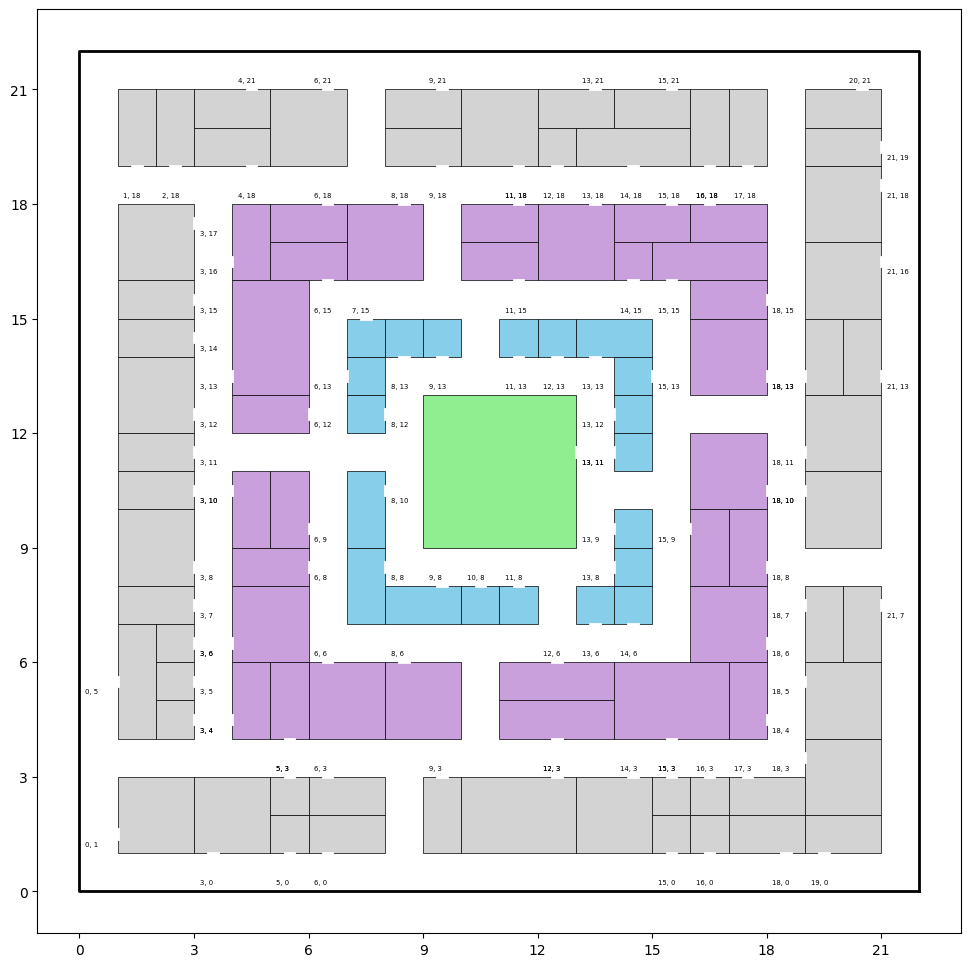

In [3]:
fig, ax = plt.subplots(figsize=(12,12))

city.plot_city(ax=ax)

# Destination Diary

In [4]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=4, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*4  # in minutes
location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 1

destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)

In [33]:
Charlie = Agent(identifier="Charlie",
                city=city)

# Convert datetime column
# destinations['datetime'] = pd.to_datetime(destinations['datetime'])
Charlie.generate_trajectory(destination_diary=destinations,
                            seed=19104,
                            dt=0.25)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=4,
                          seed=19104,
                          ha=9/15)

In [ ]:
def plot_time_barcode_colored(ts_series, cluster_labels, ax, cmap='tab20c', 
                               noise_color='black', set_xlim=True):
    """
    Plot a barcode of timestamps colored by their stop cluster.
    
    Parameters
    ----------
    ts_series : pd.Series
        Timestamps (unix seconds).
    cluster_labels : pd.Series
        Cluster labels for each timestamp (-1 for noise/non-stop points).
    ax : matplotlib.axes.Axes
        Axis to draw on.
    cmap : str or Colormap, default 'tab20c'
        Colormap for cluster colors.
    noise_color : color, default 'black'
        Color for noise points (cluster -1).
    set_xlim : bool, default True
        Auto-set x-axis limits with padding.
    
    Returns
    -------
    list
        List of vline collections.
    """
    ts_dt = pd.to_datetime(ts_series, unit='s')
    
    if set_xlim:
        pad = pd.Timedelta(minutes=20)
        ax.set_xlim(ts_dt.min() - pad, ts_dt.max() + pad)
    
    # Get unique clusters (excluding noise)
    unique_clusters = cluster_labels.unique()
    unique_clusters = unique_clusters[unique_clusters >= 0]
    num_clusters = len(unique_clusters)
    
    # Get colormap
    cmap_obj = plt.get_cmap(cmap)
    
    vlines = []
    
    # Plot noise points
    noise_mask = cluster_labels == -1
    if noise_mask.any():
        vlines.append(ax.vlines(ts_dt[noise_mask], 0.2, 0.8, 
                                colors=noise_color, lw=1, alpha=0.5))
    
    # Plot each cluster with its color
    if num_clusters > 0:
        for cid in unique_clusters:
            cluster_mask = cluster_labels == cid
            if cluster_mask.any():
                col = cmap_obj(cid / num_clusters)
                vlines.append(ax.vlines(ts_dt[cluster_mask], 0.2, 0.8, 
                                       colors=col, lw=1, alpha=1, zorder=2))
    
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    
    # Time axis formatting
    time_range = (ts_dt.max() - ts_dt.min()).total_seconds()
    
    if time_range <= 3600 * 12:
        major_locator = mdates.HourLocator(interval=1)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = None
    elif time_range <= 3600 * 72:
        major_locator = mdates.HourLocator(interval=6)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = mdates.HourLocator(interval=1)
    else:
        major_locator = mdates.DayLocator()
        formatter = mdates.DateFormatter('%a\n%I %p')
        minor_locator = mdates.HourLocator(interval=6)
    
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(formatter)
    
    if minor_locator is not None:
        ax.xaxis.set_minor_locator(minor_locator)
        ax.tick_params(axis='x', which='minor', length=3)
    
    ax.tick_params(axis='x', which='major', labelsize=10)
    
    return vlines

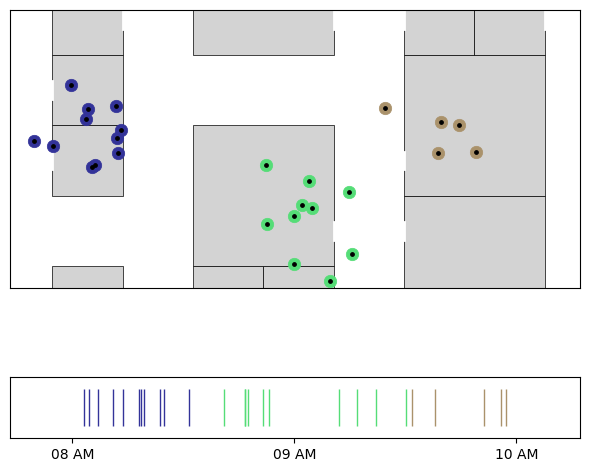

<Figure size 640x480 with 0 Axes>

In [71]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

# colors = {
#                 'street': 'white',
#                 'home': 'skyblue',
#                 'workplace': '#C9A0DC',
#                 'retail': 'lightgrey',
#                 'park': 'lightgreen',
#                 'default': 'lightcoral'
#             }

# labels = LACHESIS.lachesis_labels(
#     data=Charlie.sparse_traj,
#     dt_max=15,
#     delta_roam=2.8,
#     dur_min=5,
#     traj_cols=tc)

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=30,
    delta_roam=2,
    dur_min=5)

# labels = DBSCAN.ta_dbscan(
#     data=Charlie.sparse_traj,
#     time_thresh=600,
#     dist_thresh=0.8,
#     min_pts=3,
#     dur_min=5,
#     traj_cols=tc)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

# ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
#            color='red', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_clusters.svg', format='svg')

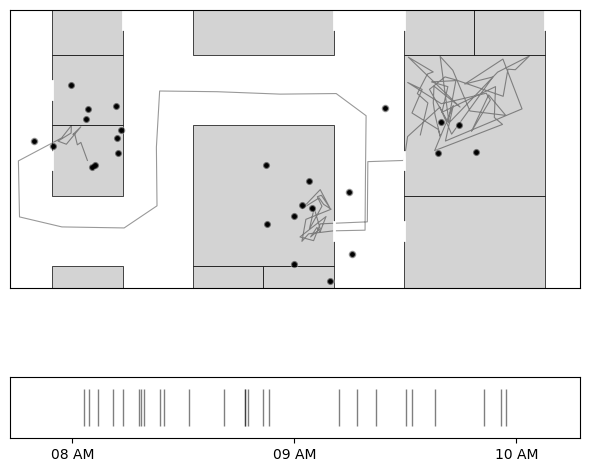

<Figure size 640x480 with 0 Axes>

In [72]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

# colors = {
#                 'street': 'white',
#                 'home': 'skyblue',
#                 'workplace': '#C9A0DC',
#                 'retail': 'lightgrey',
#                 'park': 'lightgreen',
#                 'default': 'lightcoral'
#             }

# labels = LACHESIS.lachesis_labels(
#     data=Charlie.sparse_traj,
#     dt_max=15,
#     delta_roam=2.8,
#     dur_min=5,
#     traj_cols=tc)

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=1,
    delta_roam=1,
    dur_min=5)

# labels = DBSCAN.ta_dbscan(
#     data=Charlie.sparse_traj,
#     time_thresh=600,
#     dist_thresh=0.8,
#     min_pts=3,
#     dur_min=5,
#     traj_cols=tc)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
           color='black', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_traj_only.svg', format='svg')